In [8]:
import numpy as np

dataset = np.load("dataset.npz")
X, y = dataset["X"], dataset["y"]

In [9]:
from sklearn.model_selection import train_test_split

seed = 67

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=67, stratify=y)

In [10]:
from sklearn.metrics import fbeta_score, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold

"""
def f2(y_true, y_pred):
    # We want the F2-score of virus vs not-virus
    return fbeta_score(y_true=(y_true != 0).astype(int), y_pred=(y_pred != 0).astype(int), beta=2)
"""

def macro_f1(y_true, y_pred):
    # We want the mean F1-score of all virus labels 1-9
    return f1_score(y_true=y_true, y_pred=y_pred, labels=range(1,10), average="macro")

"""
scorer = {
    "f2": make_scorer(f2),
    "macro_f1": make_scorer(macro_f1)
}
"""

"""
def prio(cv_results):
    # Pick candidates using an f2-threshold and pick a winner using macro_f1
    f2_scores = np.array(cv_results["mean_test_f2"])
    f1_macro_scores = np.array(cv_results["mean_test_macro_f1"])

    tolerance = 0.01
    passing = f2_scores >= f2_scores.max() - tolerance

    return int(np.argmax(np.where(passing, f1_macro_scores, -np.inf)))
"""

scorer = make_scorer(macro_f1)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=seed)

param_grid_dt = {
    "max_depth": [2, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [2, 5],
    "criterion": ["entropy", "gini"]
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv
)

grid_search_dt.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': [2, 5, ...], 'min_samples_leaf': [2, 5], 'min_samples_split': [2, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:

              precision    recall  f1-score   support

           0       0.28      0.12      0.16       113
           1       0.99      0.99      0.99       346
           2       0.58      0.56      0.57       137
           3       0.90      0.82      0.86       108
           4       1.00      1.00      1.00        36
           5       0.70      0.72      0.71       300
           6       0.74      0.84      0.79       692
           7       0.63      0.63      0.63       337
           8       0.54      0.44      0.49       116
           9       0.76      0.74      0.75       150

    accuracy                           0.74      2335
   macro avg       0.71      0.69      0.69      2335
weighted avg       0.73      0.74      0.73      2335

Macro-F1: 0.7524489169261055
F2: 0.6878544771433845


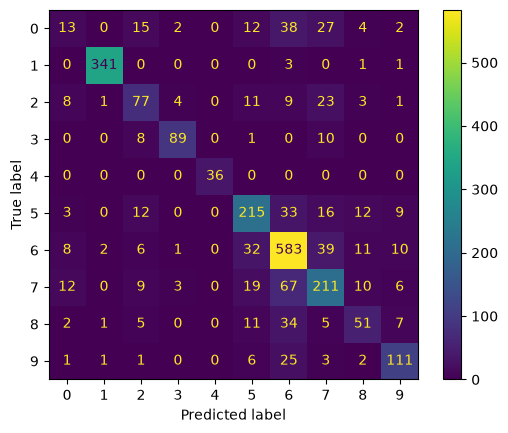

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_dt = grid_search_dt.best_estimator_

y_pred_dt = best_model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print(f"Macro-F1: {macro_f1(y_test, y_pred_dt)}")
print(f"F2: {fbeta_score(y_test, y_pred_dt, beta=2, average="macro")}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
cmd_dt = ConfusionMatrixDisplay(cm_dt)
cmd_dt.plot()
plt.show()

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe_mlp = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", MLPClassifier(random_state=seed))
])

param_grid_mlp = {
    "model__hidden_layer_sizes": [(128,), (64,), (64, 32,)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01]
}

grid_search_mlp = GridSearchCV(
    estimator=pipe_mlp,
    param_grid=param_grid_mlp,
    scoring=scorer,
    n_jobs=-1,
    refit=True,
    cv=cv
)

grid_search_mlp.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=67))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__activation': ['relu', 'tanh'], 'model__alpha': [0.001, 0.01], 'model__hidden_layer_sizes': [(128,), (64,), ...], 'model__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplex

              precision    recall  f1-score   support

           0       0.30      0.20      0.24       113
           1       0.99      1.00      0.99       346
           2       0.86      0.85      0.86       137
           3       0.96      0.95      0.96       108
           4       1.00      1.00      1.00        36
           5       0.86      0.83      0.84       300
           6       0.90      0.93      0.91       692
           7       0.80      0.84      0.82       337
           8       0.84      0.78      0.81       116
           9       0.83      0.89      0.86       150

    accuracy                           0.87      2335
   macro avg       0.83      0.83      0.83      2335
weighted avg       0.86      0.87      0.86      2335

Macro-F1: 0.8952580360315745
F2: 0.8289398807556596


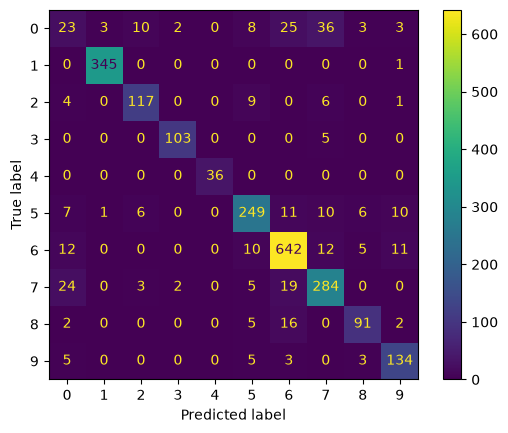

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model_mlp = grid_search_mlp.best_estimator_

y_pred_mlp = best_model_mlp.predict(X_test)
print(classification_report(y_test, y_pred_mlp))
print(f"Macro-F1: {macro_f1(y_test, y_pred_mlp)}")
print(f"F2: {fbeta_score(y_test, y_pred_mlp, beta=2, average="macro")}")

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
cmd_mlp = ConfusionMatrixDisplay(cm_mlp)
cmd_mlp.plot()
plt.show()